#Stopword

##Instalasi dan Import Library

In [1]:
!pip install google_play_scraper
!pip install PySastrawi
!pip install matplotlib seaborn

from google_play_scraper import app
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk

# Konfigurasi tampilan
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15, 8)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 4.1 MB/s eta 0:00:00


##Import Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/PBA/rawdata_jenius_id.csv'

df_jenius = pd.read_csv(file_path, low_memory=False)
print(f'✅ Dataset berhasil dimuat dari "{file_path}"')
display(df_jenius.head())

Mounted at /content/drive
✅ Dataset berhasil dimuat dari "/content/drive/My Drive/PBA/rawdata_jenius_id.csv"


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c4fff659-dc8d-4449-92bd-c31e47cce376,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"payah udah cape"" isi data , login suruh isi da...",1,0,4.66.1,2026-03-23 09:31:49,Mohon maaf atas ketidaknyamanan yang kamu alam...,2026-03-23 09:32:47,4.66.1
1,cbfc7f4a-d5f6-48ef-a6f6-2a30ea8e159d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mohon bantu saya tidak pernah mengajukan pinja...,1,0,4.66.1,2026-03-23 07:25:07,Hi Sarwedi Silalahi. Mohon maaf atas ketidakny...,2026-03-23 07:32:36,4.66.1
2,163b3f92-772b-41d5-9c89-2d083ed3a355,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mobile banking paling berat dan lambat yang pe...,1,0,4.66.1,2026-03-22 23:24:37,Hi Kusnadi. Mohon maaf atas ketidaknyamanannya...,2026-03-22 23:31:12,4.66.1
3,b0eb2070-29d3-4f1d-b525-b2ecc70d0bda,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"tolong perbaiki sistemnya ya, kita sudah berus...",1,0,NaN,2026-03-22 13:33:56,Hai Andhy Hutomo. Terima kasih atas ulasan yan...,2026-03-22 13:35:34,NaN
4,e265485e-090f-4b1c-9a0b-6df7bdadebfd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya ingin unlink device, tapi sangat sulit. s...",1,0,4.66.1,2026-03-22 11:17:12,Hi Kak. Mohon maaf atas ketidaknyamanan yang d...,2026-03-22 11:19:39,4.66.1


In [3]:
df_jenius

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c4fff659-dc8d-4449-92bd-c31e47cce376,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"payah udah cape"" isi data , login suruh isi da...",1,0,4.66.1,2026-03-23 09:31:49,Mohon maaf atas ketidaknyamanan yang kamu alam...,2026-03-23 09:32:47,4.66.1
1,cbfc7f4a-d5f6-48ef-a6f6-2a30ea8e159d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mohon bantu saya tidak pernah mengajukan pinja...,1,0,4.66.1,2026-03-23 07:25:07,Hi Sarwedi Silalahi. Mohon maaf atas ketidakny...,2026-03-23 07:32:36,4.66.1
2,163b3f92-772b-41d5-9c89-2d083ed3a355,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mobile banking paling berat dan lambat yang pe...,1,0,4.66.1,2026-03-22 23:24:37,Hi Kusnadi. Mohon maaf atas ketidaknyamanannya...,2026-03-22 23:31:12,4.66.1
3,b0eb2070-29d3-4f1d-b525-b2ecc70d0bda,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"tolong perbaiki sistemnya ya, kita sudah berus...",1,0,NaN,2026-03-22 13:33:56,Hai Andhy Hutomo. Terima kasih atas ulasan yan...,2026-03-22 13:35:34,NaN
4,e265485e-090f-4b1c-9a0b-6df7bdadebfd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya ingin unlink device, tapi sangat sulit. s...",1,0,4.66.1,2026-03-22 11:17:12,Hi Kak. Mohon maaf atas ketidaknyamanan yang d...,2026-03-22 11:19:39,4.66.1
...,...,...,...,...,...,...,...,...,...,...,...
101146,d4774bcb-cd37-4794-aafc-71418f71b71a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"ah bijimana aplikasi ini ?,,gw register proses...",1,19,1.0.0,2016-08-11 07:47:19,"Hi Nesken Sitangggang, terima kasih telah men-...",2016-08-13 15:54:29,1.0.0
101147,d2025bb4-9836-4868-8d0d-1d0317cda408,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus,4,0,NaN,2016-08-11 07:12:12,"Thank you, Miftah Dewa\nLet's discover a new w...",2016-09-06 09:57:34,NaN
101148,b16f046a-0a3e-4f34-b68e-03cd8a51bcde,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Jenius abis,5,3,1.0.0,2016-08-11 06:45:11,"Thank you, Helve Krustiarnando\nLet's discover...",2016-09-06 09:55:44,1.0.0
101149,9298f6dd-4269-4d68-80ca-0ebc29190a60,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Ada error di bagian regist. Enggak tau apa cum...,3,12,1.0.0,2016-08-11 06:00:25,"Hi Syifa Chairannisa, terima kasih telah mengu...",2016-08-13 16:14:27,1.0.0


##Periksa Struktur Dataset

In [4]:
# Pemeriksaan tipe data dan nilai kosong pada setiap kolom
df_jenius.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101151 entries, 0 to 101150
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              101151 non-null  object
 1   userName              101151 non-null  object
 2   userImage             101151 non-null  object
 3   content               101147 non-null  object
 4   score                 101151 non-null  int64 
 5   thumbsUpCount         101151 non-null  int64 
 6   reviewCreatedVersion  69106 non-null   object
 7   at                    101151 non-null  object
 8   replyContent          29697 non-null   object
 9   repliedAt             29697 non-null   object
 10  appVersion            69106 non-null   object
dtypes: int64(2), object(9)
memory usage: 8.5+ MB


##Pengambilan Kolom Relevan

In [5]:
# Kolom seperti reviewId, userName, dan userImage
# tidak diperlukan dalam analisis sentimen

df_jenius.loc[:, ["content", "score", "thumbsUpCount",
                   "reviewCreatedVersion", "at",
                   "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,"payah udah cape"" isi data , login suruh isi da...",1,0,4.66.1,2026-03-23 09:31:49,Mohon maaf atas ketidaknyamanan yang kamu alam...,2026-03-23 09:32:47
1,mohon bantu saya tidak pernah mengajukan pinja...,1,0,4.66.1,2026-03-23 07:25:07,Hi Sarwedi Silalahi. Mohon maaf atas ketidakny...,2026-03-23 07:32:36
2,mobile banking paling berat dan lambat yang pe...,1,0,4.66.1,2026-03-22 23:24:37,Hi Kusnadi. Mohon maaf atas ketidaknyamanannya...,2026-03-22 23:31:12
3,"tolong perbaiki sistemnya ya, kita sudah berus...",1,0,NaN,2026-03-22 13:33:56,Hai Andhy Hutomo. Terima kasih atas ulasan yan...,2026-03-22 13:35:34
4,"saya ingin unlink device, tapi sangat sulit. s...",1,0,4.66.1,2026-03-22 11:17:12,Hi Kak. Mohon maaf atas ketidaknyamanan yang d...,2026-03-22 11:19:39
...,...,...,...,...,...,...,...
101146,"ah bijimana aplikasi ini ?,,gw register proses...",1,19,1.0.0,2016-08-11 07:47:19,"Hi Nesken Sitangggang, terima kasih telah men-...",2016-08-13 15:54:29
101147,Bagus,4,0,NaN,2016-08-11 07:12:12,"Thank you, Miftah Dewa\nLet's discover a new w...",2016-09-06 09:57:34
101148,Jenius abis,5,3,1.0.0,2016-08-11 06:45:11,"Thank you, Helve Krustiarnando\nLet's discover...",2016-09-06 09:55:44
101149,Ada error di bagian regist. Enggak tau apa cum...,3,12,1.0.0,2016-08-11 06:00:25,"Hi Syifa Chairannisa, terima kasih telah mengu...",2016-08-13 16:14:27


##Inisiasi Stopwords

In [6]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Memuat daftar stopwords bahasa Indonesia dari Sastrawi
factory = StopWordRemoverFactory()
indo_stopwords = set(factory.get_stop_words())

# Verifikasi jumlah stopwords
print(f'Total stopwords Sastrawi: {len(indo_stopwords)}')
print('\n20 stopwords pertama:')
print(list(indo_stopwords)[:20])

Total stopwords Sastrawi: 809

20 stopwords pertama:
['sebab', 'y', 'sesuatu', 'dimisalkan', 'terutama', 'bung', 'awalnya', 'keseluruhannya', 'diungkapkan', 'seperti', 'seorang', 'menjadi', 'setiap', 'jangan', 'kinilah', 'ditanyakan', 'tahu', 'sebagaimana', 'karenanya', 'masing-masing']


,Kata,Frekuensi
0,aplikasi,45492
1,jenius,28286
2,mudah,15547
3,banget,11844
4,bagus,11381
...,...,...
95,e-wallet,1680
96,"spotify,",1680
97,financial,1652
98,email,1609


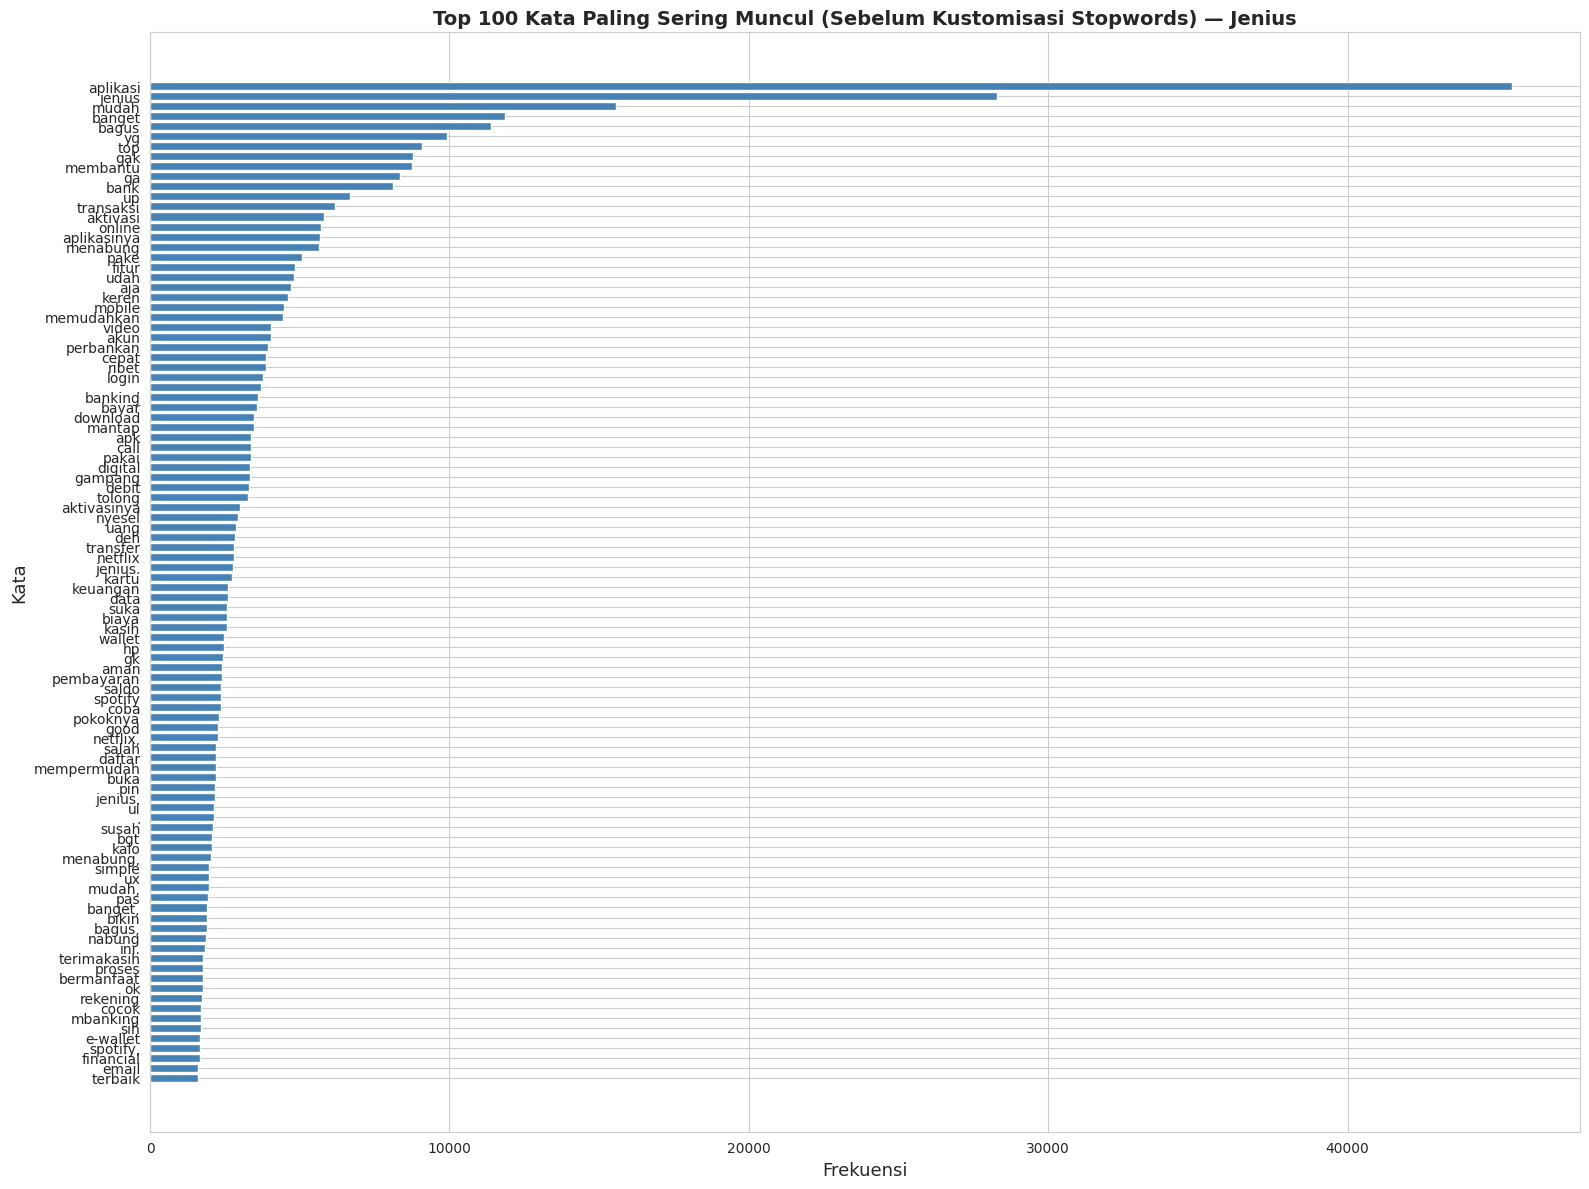

In [7]:
# Gabungkan seluruh teks ulasan menjadi satu string
semua_teks = ' '.join(df_jenius['content'].dropna().astype(str))

# Tokenisasi dan hapus stopwords Sastrawi
kata_semua = semua_teks.lower().split()
kata_terfilter = [kata for kata in kata_semua if kata not in indo_stopwords]

# Hitung frekuensi
frekuensi_kata = Counter(kata_terfilter)
kata_umum = frekuensi_kata.most_common(100)

# Konversi ke DataFrame
df_frekuensi = pd.DataFrame(kata_umum, columns=['Kata', 'Frekuensi'])
display(df_frekuensi)

# Visualisasi
plt.figure(figsize=(16, 12))
plt.barh(df_frekuensi['Kata'][::-1], df_frekuensi['Frekuensi'][::-1], color='steelblue')
plt.xlabel('Frekuensi', fontsize=13)
plt.ylabel('Kata', fontsize=13)
plt.title('Top 100 Kata Paling Sering Muncul (Sebelum Kustomisasi Stopwords) — Jenius',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##Kostomisasi Stopwords

In [10]:
# Kata-kata yang sering muncul namun tidak memiliki
# nilai sentimen ditambahkan ke dalam daftar stopwords

custom_stopwords = [
    # 1. Istilah domain aplikasi perbankan
    'aplikasi', 'jenius', 'bank', 'btpn', 'app', 'fitur',
    'akun', 'rekening', 'transfer', 'saldo', 'kartu',
    'transaksi', 'virtual', 'login', 'verifikasi', 'user',

    # 2. Kata kerja & kata umum netral
    'bisa', 'mau', 'mau', 'perlu', 'pakai', 'pake',
    'coba', 'kasih', 'bilang', 'minta', 'lagi', 'udah',
    'sudah', 'belum', 'kalau', 'kalo', 'kalau', 'ada', 'adalah', 'adanya', 'adapun', 'aja',

    # 3. Kata ganti & kata seru
    'saya', 'aku', 'gue', 'gw', 'kamu', 'anda',
    'nya', 'si', 'pak', 'bu', 'mas', 'kak',
    'nih', 'tuh', 'aja', 'deh', 'dong', 'sih',
    'yah', 'wah', 'aduh', 'oke', 'ok', 'ya',

    # 4. Kata waktu & kuantitas
    'hari', 'minggu', 'bulan', 'tahun', 'lama',
    'cepat', 'lama', 'kali', 'jam', 'menit',
    'pertama', 'kedua', 'terakhir',

    # 5. Simbol & residu tanda baca
    'amp', '&', '.', ',', '-', '!', '?',
    '1', '2', '3', '4', '5',
]

# Gabungkan stopwords Sastrawi dengan custom stopwords
indo_stopwords.update(custom_stopwords)

print(f'Total stopwords setelah kustomisasi: {len(indo_stopwords)}')

Total stopwords setelah kustomisasi: 864


In [9]:
indo_stopwords

{'!',
 '&',
 ',',
 '-',
 '.',
 '1',
 '2',
 '3',
 '4',
 '5',
 '?',
 'a',
 'ada',
 'adalah',
 'adanya',
 'adapun',
 'aduh',
 'agak',
 'agaknya',
 'agar',
 'aja',
 'akan',
 'akankah',
 'akhir',
 'akhiri',
 'akhirnya',
 'aku',
 'akulah',
 'akun',
 'amat',
 'amatlah',
 'amp',
 'anda',
 'andalah',
 'antar',
 'antara',
 'antaranya',
 'apa',
 'apaan',
 'apabila',
 'apakah',
 'apalagi',
 'apatah',
 'aplikasi',
 'app',
 'arti',
 'artinya',
 'asal',
 'asalkan',
 'atas',
 'atau',
 'ataukah',
 'ataupun',
 'awal',
 'awalnya',
 'b',
 'bagai',
 'bagaikan',
 'bagaimana',
 'bagaimanakah',
 'bagaimanapun',
 'bagainamakah',
 'bagi',
 'bagian',
 'bahkan',
 'bahwa',
 'bahwasannya',
 'bahwasanya',
 'baik',
 'baiklah',
 'bakal',
 'bakalan',
 'balik',
 'bank',
 'banyak',
 'bapak',
 'baru',
 'bawah',
 'beberapa',
 'begini',
 'beginian',
 'beginikah',
 'beginilah',
 'begitu',
 'begitukah',
 'begitulah',
 'begitupun',
 'bekerja',
 'belakang',
 'belakangan',
 'belum',
 'belumlah',
 'benar',
 'benarkah',
 'benarlah

##Analisis Hasil Pembersihan

=== TOP 100 KATA SETELAH PEMBERSIHAN ===
[('mudah', 15547), ('banget', 11844), ('bagus', 11381), ('top', 9076), ('gak', 8783), ('membantu', 8754), ('aktivasi', 5804), ('online', 5701), ('aplikasinya', 5659), ('menabung', 5632), ('keren', 4608), ('mobile', 4473), ('memudahkan', 4447), ('video', 4040), ('perbankan', 3949), ('ribet', 3876), ('banking', 3598), ('bayar', 3562), ('download', 3473), ('mantap', 3459), ('apk', 3385), ('call', 3359), ('digital', 3351), ('gampang', 3338), ('debit', 3293), ('tolong', 3269), ('aktivasinya', 2990), ('nyesel', 2937), ('uang', 2856), ('netflix', 2793), ('jenius.', 2759), ('keuangan', 2599), ('data', 2587), ('suka', 2578), ('biaya', 2570), ('wallet', 2472), ('aman', 2407), ('pembayaran', 2388), ('spotify', 2360), ('pokoknya', 2294), ('good', 2263), ('netflix,', 2257), ('salah', 2192), ('daftar', 2188), ('mempermudah', 2187), ('buka', 2185), ('pin', 2180), ('jenius,', 2159), ('susah', 2091), ('bgt', 2075), ('menabung,', 2027), ('simple', 1981), ('mudah,

,Kata,Frekuensi
0,mudah,15547
1,banget,11844
2,bagus,11381
3,top,9076
4,gak,8783
...,...,...
95,"banking,",1170
96,sesi,1155
97,tinggal,1134
98,"e-wallet,",1126


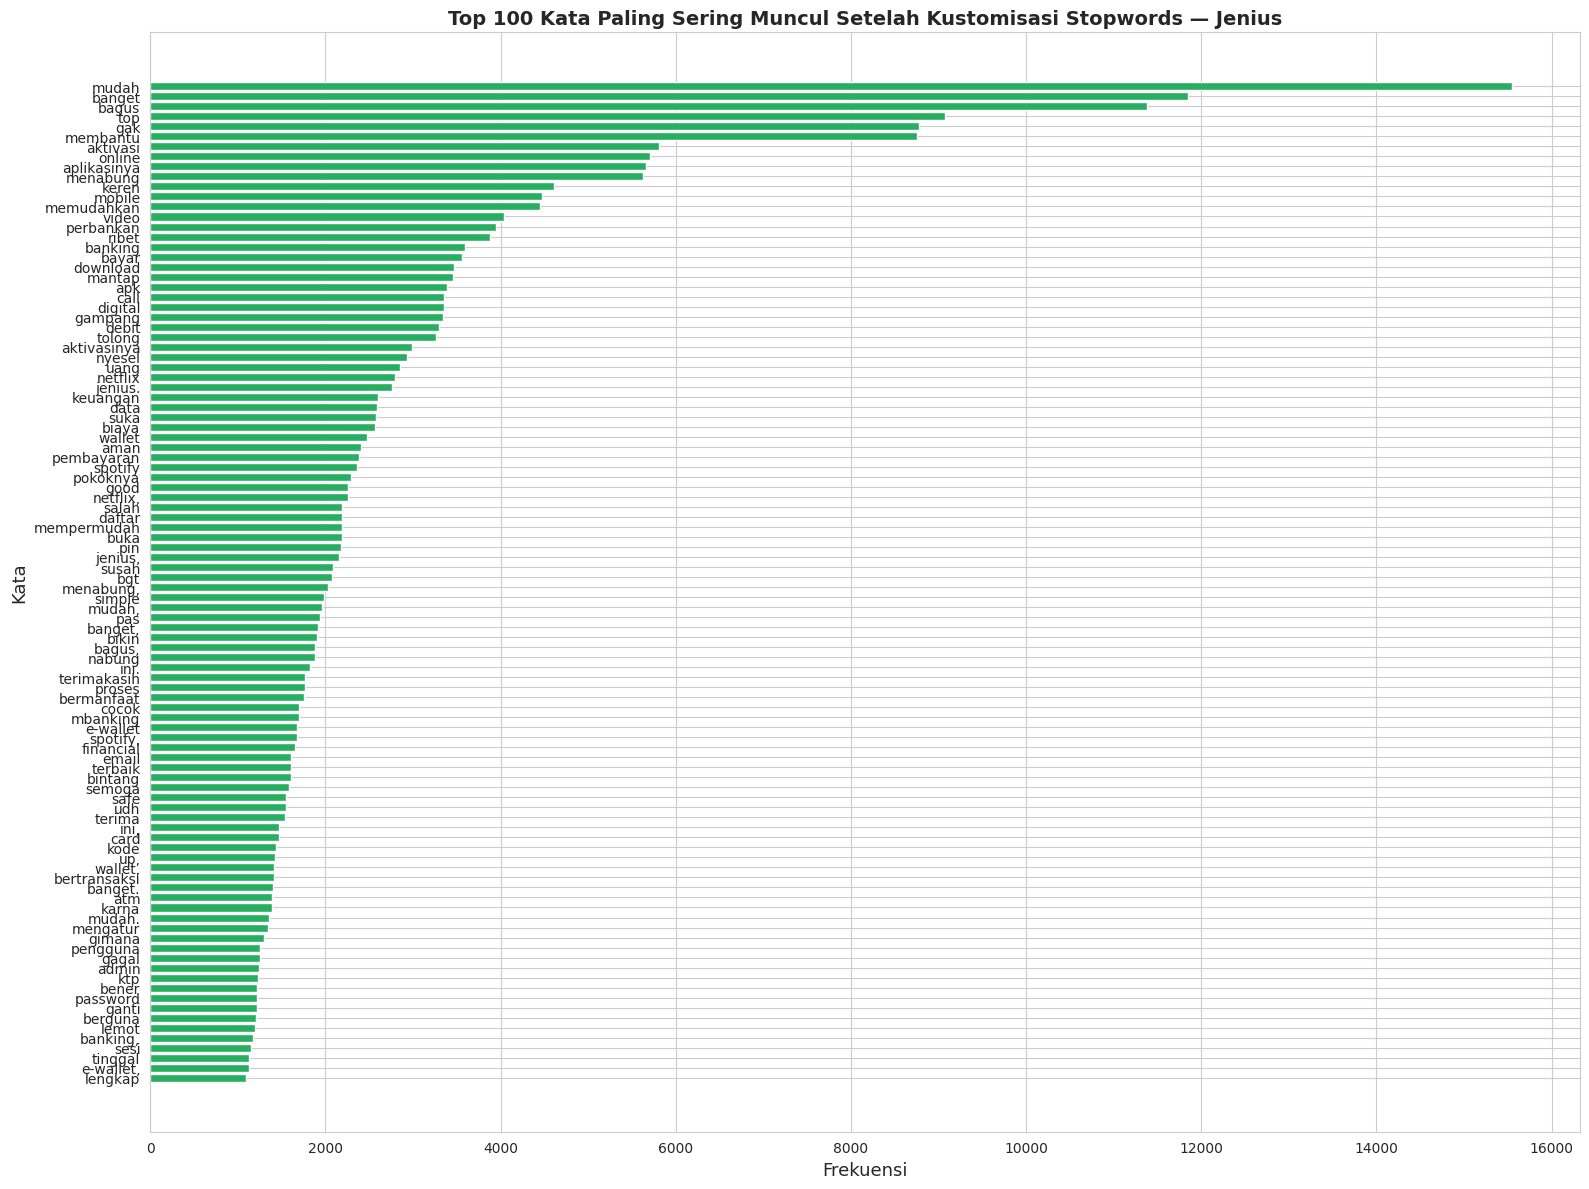

In [11]:
# Tokenisasi ulang dengan stopwords yang telah dikustomisasi
kata_bersih = [kata for kata in kata_semua if kata not in indo_stopwords and len(kata) > 2]

# Hitung frekuensi kata bersih
frekuensi_bersih = Counter(kata_bersih)
kata_umum_bersih = frekuensi_bersih.most_common(100)

# Konversi ke DataFrame
df_frekuensi_bersih = pd.DataFrame(kata_umum_bersih, columns=['Kata', 'Frekuensi'])

print('=== TOP 100 KATA SETELAH PEMBERSIHAN ===')
print(kata_umum_bersih)
display(df_frekuensi_bersih)

# Visualisasi
plt.figure(figsize=(16, 12))
plt.barh(df_frekuensi_bersih['Kata'][::-1], df_frekuensi_bersih['Frekuensi'][::-1],
         color='#27ae60', edgecolor='white')
plt.xlabel('Frekuensi', fontsize=13)
plt.ylabel('Kata', fontsize=13)
plt.title('Top 100 Kata Paling Sering Muncul Setelah Kustomisasi Stopwords — Jenius',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#Stemming

,Kata Dasar,Frekuensi
0,mudah,27247
1,banget,15840
2,bagus,14411
3,bantu,11588
4,tabung,9482
5,top,9229
6,gak,8860
7,bayar,7604
8,online,7596
9,jenius,7568


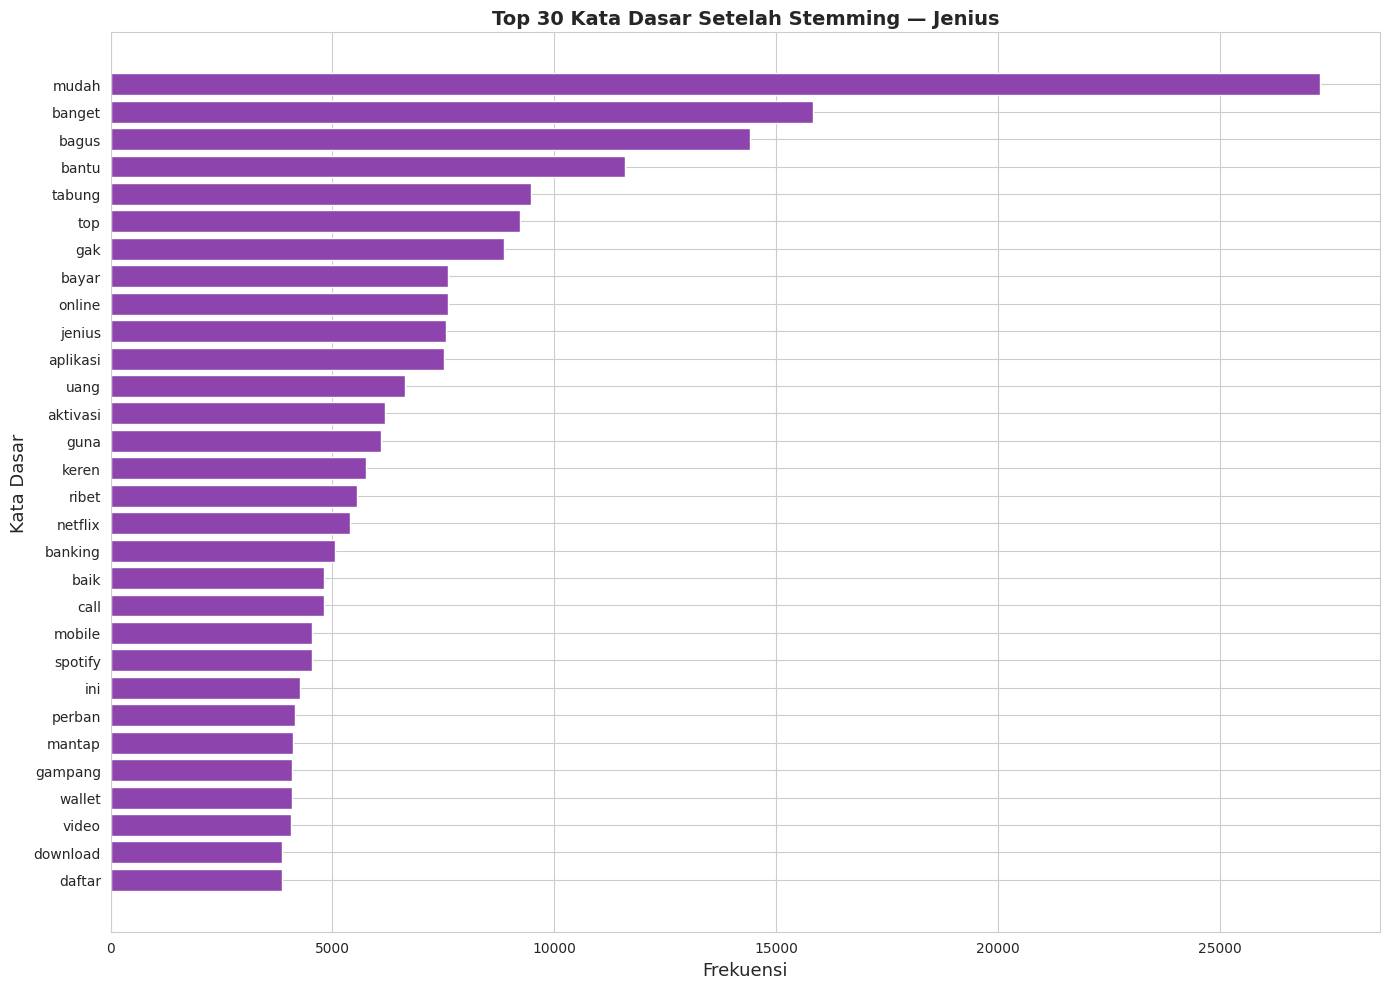

In [12]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

# Stemming seluruh kata bersih
kata_stemmed = [stemmer.stem(kata) for kata in kata_bersih]

# Hitung frekuensi setelah stemming
frekuensi_stemmed = Counter(kata_stemmed)
kata_umum_stemmed = frekuensi_stemmed.most_common(100)

df_stemmed_freq = pd.DataFrame(kata_umum_stemmed, columns=['Kata Dasar', 'Frekuensi'])
display(df_stemmed_freq.head(20))

# Visualisasi top 30 kata dasar
top30 = df_stemmed_freq.head(30)
plt.figure(figsize=(14, 10))
plt.barh(top30['Kata Dasar'][::-1], top30['Frekuensi'][::-1],
         color='#8e44ad', edgecolor='white')
plt.xlabel('Frekuensi', fontsize=13)
plt.ylabel('Kata Dasar', fontsize=13)
plt.title('Top 30 Kata Dasar Setelah Stemming — Jenius',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#Preprocessing

##Instalasi Library

In [15]:
!pip install PySastrawi
!pip install langid
!pip install symspellpy

import pandas as pd
import numpy as np
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import string
import re
import langid

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

##Load Dataset

In [16]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/PBA/rawdata_jenius_id.csv'

df_jenius = pd.read_csv(file_path, low_memory=False)
print(f'✅ Dataset berhasil dimuat: {len(df_jenius):,} baris')
display(df_jenius.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset berhasil dimuat: 101,151 baris


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c4fff659-dc8d-4449-92bd-c31e47cce376,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"payah udah cape"" isi data , login suruh isi da...",1,0,4.66.1,2026-03-23 09:31:49,Mohon maaf atas ketidaknyamanan yang kamu alam...,2026-03-23 09:32:47,4.66.1
1,cbfc7f4a-d5f6-48ef-a6f6-2a30ea8e159d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mohon bantu saya tidak pernah mengajukan pinja...,1,0,4.66.1,2026-03-23 07:25:07,Hi Sarwedi Silalahi. Mohon maaf atas ketidakny...,2026-03-23 07:32:36,4.66.1
2,163b3f92-772b-41d5-9c89-2d083ed3a355,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mobile banking paling berat dan lambat yang pe...,1,0,4.66.1,2026-03-22 23:24:37,Hi Kusnadi. Mohon maaf atas ketidaknyamanannya...,2026-03-22 23:31:12,4.66.1
3,b0eb2070-29d3-4f1d-b525-b2ecc70d0bda,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"tolong perbaiki sistemnya ya, kita sudah berus...",1,0,NaN,2026-03-22 13:33:56,Hai Andhy Hutomo. Terima kasih atas ulasan yan...,2026-03-22 13:35:34,NaN
4,e265485e-090f-4b1c-9a0b-6df7bdadebfd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya ingin unlink device, tapi sangat sulit. s...",1,0,4.66.1,2026-03-22 11:17:12,Hi Kak. Mohon maaf atas ketidaknyamanan yang d...,2026-03-22 11:19:39,4.66.1


## Konversi Format Waktu

In [18]:
df_jenius['at'] = pd.to_datetime(df_jenius['at'])
df_jenius.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101151 entries, 0 to 101150
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              101151 non-null  object        
 1   userName              101151 non-null  object        
 2   userImage             101151 non-null  object        
 3   content               101147 non-null  object        
 4   score                 101151 non-null  int64         
 5   thumbsUpCount         101151 non-null  int64         
 6   reviewCreatedVersion  69106 non-null   object        
 7   at                    101151 non-null  datetime64[ns]
 8   replyContent          29697 non-null   object        
 9   repliedAt             29697 non-null   object        
 10  appVersion            69106 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 8.5+ MB


##Hapus Kolom Ridak Relevan & Tangani Missing Values

In [19]:
#Cek missing values
df_jenius.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,4
score,0
thumbsUpCount,0
reviewCreatedVersion,32045
at,0
replyContent,71454
repliedAt,71454


In [26]:
# Hapus kolom metadata yang tidak dibutuhkan dalam analisis sentimen
#akan error kalau code sudah pernah dijalankan
df_jenius = df_jenius.drop(columns=['userName', 'userImage'])


KeyError: "['userName', 'userImage'] not found in axis"

In [25]:
# Hapus baris yang kolom ulasannya kosong
df_jenius = df_jenius.dropna(subset=['content'])

# Isi nilai kosong pada kolom balasan dengan label 'Tidak Ada Balasan'
df_jenius['replyContent'] = df_jenius['replyContent'].fillna('Tidak Ada Balasan')
df_jenius['repliedAt']    = df_jenius['repliedAt'].fillna('Tidak Ada Balasan')
df_jenius['reviewCreatedVersion']    = df_jenius['reviewCreatedVersion'].fillna('Null')
df_jenius['appVersion']    = df_jenius['appVersion'].fillna('Null')


print('=== MISSING VALUES SETELAH PEMBERSIHAN ===')
print(df_jenius.isnull().sum())
print(f'\nJumlah ulasan tersisa: {len(df_jenius):,}')

=== MISSING VALUES SETELAH PEMBERSIHAN ===
reviewId                0
content                 0
score                   0
thumbsUpCount           0
reviewCreatedVersion    0
at                      0
replyContent            0
repliedAt               0
appVersion              0
dtype: int64

Jumlah ulasan tersisa: 101,147


##Frekuensi Kata Sebelum Preprocessing

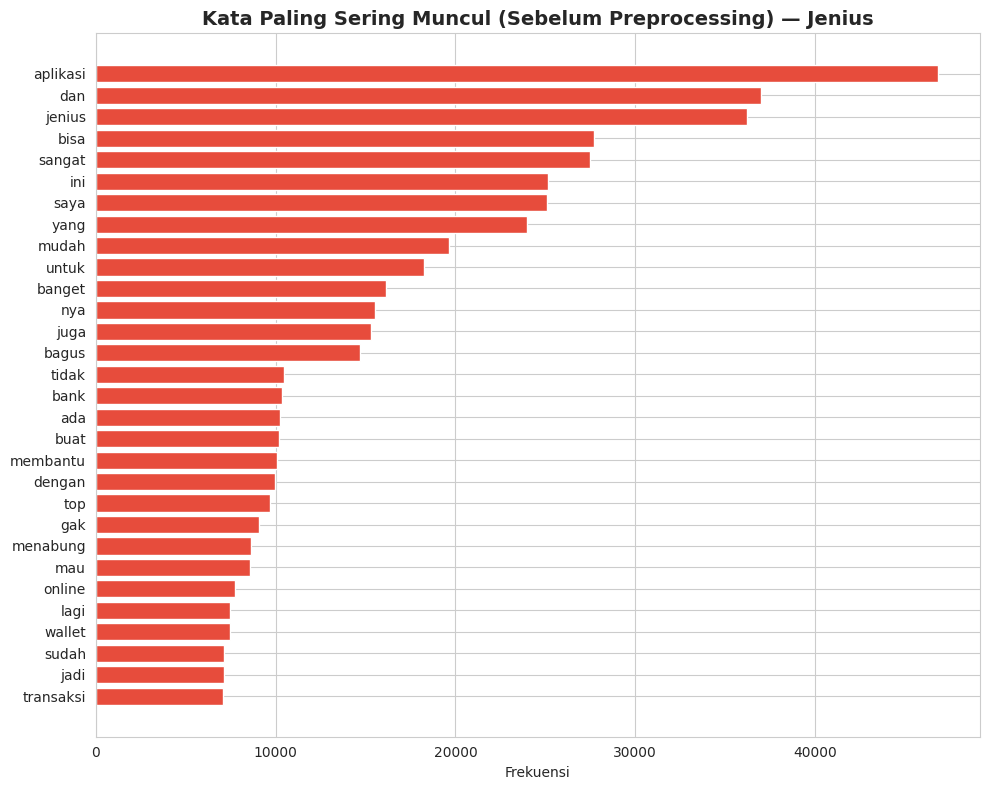

In [27]:
all_text = ' '.join(df_jenius['content'].dropna()).lower()
words = re.findall(r'\b[a-zA-Z]{3,}\b', all_text)
word_counts_raw = Counter(words).most_common(30)
labels_raw, values_raw = zip(*word_counts_raw)

plt.figure(figsize=(10, 8))
plt.barh(labels_raw, values_raw, color='#e74c3c', edgecolor='white')
plt.title('Kata Paling Sering Muncul (Sebelum Preprocessing) — Jenius',
          fontsize=14, fontweight='bold')
plt.xlabel('Frekuensi')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##Deteksi dan Filter Bahasa Indonesia

In [28]:
from multiprocessing import Pool, cpu_count

def deteksi_bahasa(teks):
    try:
        if isinstance(teks, str) and len(teks.strip()) > 5:
            bahasa, _ = langid.classify(teks[:100])
            return bahasa
        return 'unknown'
    except:
        return 'error'

def proses_per_bagian(df_bagian):
    df_bagian['bahasa_terdeteksi'] = df_bagian['content'].apply(deteksi_bahasa)
    return df_bagian

def proses_paralel(df, fungsi):
    jumlah_core = cpu_count()
    df_terbagi = np.array_split(df, jumlah_core)
    with Pool(jumlah_core) as pool:
        hasil = pd.concat(pool.map(fungsi, df_terbagi))
    return hasil

print(f'⏳ Mendeteksi bahasa dari {len(df_jenius):,} baris...')
df_jenius = proses_paralel(df_jenius, proses_per_bagian)

# Filter hanya ulasan bahasa Indonesia
df_jenius = df_jenius[df_jenius['bahasa_terdeteksi'] == 'id'].reset_index(drop=True)

print(f'✅ Selesai! Ulasan bahasa Indonesia tersisa: {len(df_jenius):,} baris')
display(df_jenius[['content', 'bahasa_terdeteksi']].head())

⏳ Mendeteksi bahasa dari 101,147 baris...


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


✅ Selesai! Ulasan bahasa Indonesia tersisa: 77,315 baris


,content,bahasa_terdeteksi
0,"payah udah cape"" isi data , login suruh isi da...",id
1,mohon bantu saya tidak pernah mengajukan pinja...,id
2,mobile banking paling berat dan lambat yang pe...,id
3,"tolong perbaiki sistemnya ya, kita sudah berus...",id
4,"saya ingin unlink device, tapi sangat sulit. s...",id


##Ekstraksi Polaritas & Subjektivitas

In [29]:
# Polaritas dan subjektivitas dihitung sebagai fitur kuantitatif pendahuluan sebelum pemodelan menggunakan TextBlob

df_jenius['sentiment_polarity']   = df_jenius['content'].astype(str).apply(
    lambda x: TextBlob(x).polarity)
df_jenius['sentiment_subjective'] = df_jenius['content'].astype(str).apply(
    lambda x: TextBlob(x).subjectivity)

# Labeling berdasarkan skor rating
df_jenius['sentiment_rating'] = df_jenius['score'].apply(
    lambda x: 'Positif' if x > 3 else ('Netral' if x == 3 else 'Negatif'))

df_jenius.loc[:, ['content', 'score',
                   'sentiment_polarity', 'sentiment_subjective',
                   'sentiment_rating']].head()

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,"payah udah cape"" isi data , login suruh isi da...",1,0.0,0.0,Negatif
1,mohon bantu saya tidak pernah mengajukan pinja...,1,0.0,0.0,Negatif
2,mobile banking paling berat dan lambat yang pe...,1,0.0,0.0,Negatif
3,"tolong perbaiki sistemnya ya, kita sudah berus...",1,0.0,0.0,Negatif
4,"saya ingin unlink device, tapi sangat sulit. s...",1,0.0,0.0,Negatif


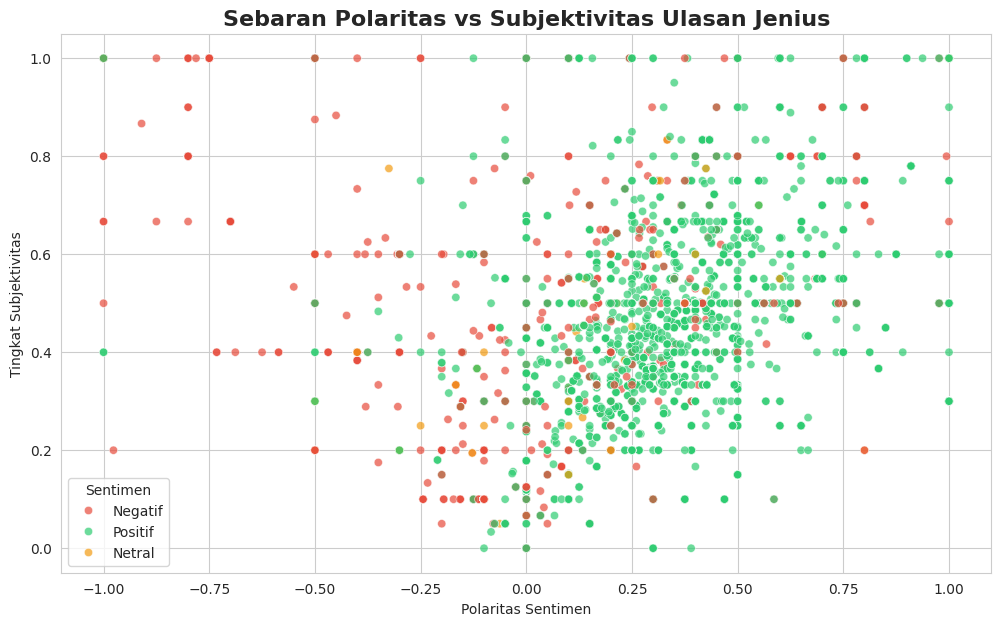

In [30]:
# Scatter plot polarity vs subjectivity
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x=df_jenius['sentiment_polarity'],
    y=df_jenius['sentiment_subjective'],
    hue=df_jenius['sentiment_rating'],
    palette={'Positif': '#2ecc71', 'Netral': '#f39c12', 'Negatif': '#e74c3c'},
    edgecolor='white', alpha=0.7
)
plt.title('Sebaran Polaritas vs Subjektivitas Ulasan Jenius',
          fontsize=16, fontweight='bold')
plt.xlabel('Polaritas Sentimen')
plt.ylabel('Tingkat Subjektivitas')
plt.legend(title='Sentimen')
plt.show()

##Tokenisasi

In [31]:
# Setiap kalimat ulasan dipecah menjadi satuan kata tunggal (token)

def lakukan_tokenisasi(teks):
    return word_tokenize(str(teks))

df_jenius['token_awal'] = df_jenius['content'].apply(lakukan_tokenisasi)

display(df_jenius[['content', 'token_awal']].head())

,content,token_awal
0,"payah udah cape"" isi data , login suruh isi da...","[payah, udah, cape, '', isi, data, ,, login, s..."
1,mohon bantu saya tidak pernah mengajukan pinja...,"[mohon, bantu, saya, tidak, pernah, mengajukan..."
2,mobile banking paling berat dan lambat yang pe...,"[mobile, banking, paling, berat, dan, lambat, ..."
3,"tolong perbaiki sistemnya ya, kita sudah berus...","[tolong, perbaiki, sistemnya, ya, ,, kita, sud..."
4,"saya ingin unlink device, tapi sangat sulit. s...","[saya, ingin, unlink, device, ,, tapi, sangat,..."


##Lowercasing

In [32]:
def ubah_ke_huruf_kecil(tokens):
    return [t.lower() for t in tokens]

df_jenius['token_lowercase'] = df_jenius['token_awal'].apply(ubah_ke_huruf_kecil)

display(df_jenius[['token_awal', 'token_lowercase']].head())

,token_awal,token_lowercase
0,"[payah, udah, cape, '', isi, data, ,, login, s...","[payah, udah, cape, '', isi, data, ,, login, s..."
1,"[mohon, bantu, saya, tidak, pernah, mengajukan...","[mohon, bantu, saya, tidak, pernah, mengajukan..."
2,"[mobile, banking, paling, berat, dan, lambat, ...","[mobile, banking, paling, berat, dan, lambat, ..."
3,"[tolong, perbaiki, sistemnya, ya, ,, kita, sud...","[tolong, perbaiki, sistemnya, ya, ,, kita, sud..."
4,"[saya, ingin, unlink, device, ,, tapi, sangat,...","[saya, ingin, unlink, device, ,, tapi, sangat,..."


##Normalisasi Slang

In [33]:
kamus_slang = {
    # Negasi
    'ga': 'tidak', 'gak': 'tidak', 'gk': 'tidak', 'ngga': 'tidak',
    'nggak': 'tidak', 'ndak': 'tidak', 'kagak': 'tidak', 'kaga': 'tidak',
    'gaada': 'tidak ada', 'gabisa': 'tidak bisa', 'gamau': 'tidak mau',
    # Kata umum
    'yg': 'yang', 'udh': 'sudah', 'udah': 'sudah', 'tp': 'tapi',
    'kalo': 'kalau', 'klo': 'kalau', 'jd': 'jadi', 'krn': 'karena',
    'utk': 'untuk', 'jg': 'juga', 'dr': 'dari', 'dgn': 'dengan',
    'sm': 'sama', 'aja': 'saja', 'aj': 'saja', 'dah': 'sudah',
    # Kata ganti
    'sy': 'saya', 'gue': 'saya', 'gw': 'saya', 'aku': 'saya',
    'bgt': 'sekali', 'bngt': 'sekali', 'banget': 'sekali',
    # Istilah Jenius
    'apk': 'aplikasi', 'hp': 'handphone', 'pake': 'pakai',
    'tf': 'transfer', 'rek': 'rekening', 'cs': 'customer service',
    'verif': 'verifikasi', 'topup': 'isi saldo', 'rb': 'ribu',
    # Keluhan teknis
    'lemot': 'lambat', 'lelet': 'lambat', 'eror': 'error',
    'ribet': 'rumit', 'nyesel': 'menyesal',
}

def normalisasi_slang(tokens):
    return [kamus_slang.get(token, token) for token in tokens]

df_jenius['token_normalisasi'] = df_jenius['token_lowercase'].apply(normalisasi_slang)

display(df_jenius[['token_lowercase', 'token_normalisasi']].head())

,token_lowercase,token_normalisasi
0,"[payah, udah, cape, '', isi, data, ,, login, s...","[payah, sudah, cape, '', isi, data, ,, login, ..."
1,"[mohon, bantu, saya, tidak, pernah, mengajukan...","[mohon, bantu, saya, tidak, pernah, mengajukan..."
2,"[mobile, banking, paling, berat, dan, lambat, ...","[mobile, banking, paling, berat, dan, lambat, ..."
3,"[tolong, perbaiki, sistemnya, ya, ,, kita, sud...","[tolong, perbaiki, sistemnya, ya, ,, kita, sud..."
4,"[saya, ingin, unlink, device, ,, tapi, sangat,...","[saya, ingin, unlink, device, ,, tapi, sangat,..."


##Stopword Removal

In [34]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopword_sastrawi = set(factory.get_stop_words())

# Kata negasi & emosi yang WAJIB dipertahankan (jangan dihapus)
# 'banget' dipertahankan karena sering memperkuat sentimen (intensifier)
# 'gak'/'tidak' dipertahankan agar tidak mengubah makna
kata_penting = {'tidak', 'bukan', 'belum', 'jangan', 'tanpa', 'kurang', 'gak', 'ga', 'nggak'}

# Custom stopwords domain Jenius (Kata yang sering muncul tapi netral/noise)
custom_stopwords_id = [
    'aplikasi', 'jenius', 'bank', 'btpn', 'fitur', 'akun',
    'rekening', 'transfer', 'saldo', 'kartu', 'transaksi',
    'login', 'verifikasi', 'bisa', 'mau', 'pakai', 'coba',
    'kasih', 'bilang', 'minta', 'lagi', 'nih', 'tuh', 'aja',
    'deh', 'dong', 'sih', 'yah', 'wah', 'oke', 'ok', 'ya',
    'hari', 'bulan', 'tahun', 'jam', 'menit', 'tapi',
    'admin', 'customer', 'service', 'e-wallet', 'digital',
    'udah', 'dah', 'ke', 'di', 'dari', 'tersebut', 'kalau',
    'kalo', 'biar', 'buat', 'kak', 'min', 'cs', 'netflix'
]

# Tambahkan angka dan simbol ke custom stopwords secara otomatis
simbol_angka = [str(i) for i in range(10)] + ['&', '.', ',', '-', '!', '?', '(', ')']
custom_stopwords_id.extend(simbol_angka)

# Gabungkan: Sastrawi + Custom - Kata Penting
stopwords_final = (stopword_sastrawi.union(set(custom_stopwords_id))) - kata_penting

def hapus_stopwords(tokens):
    return [
        token for token in tokens
        # Token harus tidak ada di list stopword DAN panjangnya lebih dari 2
        # (kecuali untuk kata penting seperti 'ga')
        if (token not in stopwords_final and len(token) > 2) or token in kata_penting
    ]

# Jalankan pembersihan
df_jenius['token_bersih'] = df_jenius['token_normalisasi'].apply(hapus_stopwords)

# Statistik
total_sebelum = df_jenius['token_normalisasi'].apply(len).sum()
total_sesudah = df_jenius['token_bersih'].apply(len).sum()
reduksi = (total_sebelum - total_sesudah) / total_sebelum * 100

print(f'Total token sebelum  : {total_sebelum:,}')
print(f'Total token sesudah  : {total_sesudah:,}')
print(f'Persentase reduksi   : {reduksi:.2f}%')
print(f'Total stopwords aktif: {len(stopwords_final)}')

display(df_jenius[['token_normalisasi', 'token_bersih']].head())

Total token sebelum  : 1,620,276
Total token sesudah  : 655,204
Persentase reduksi   : 59.56%
Total stopwords aktif: 862


,token_normalisasi,token_bersih
0,"[payah, sudah, cape, '', isi, data, ,, login, ...","[payah, cape, isi, data, suruh, isi, data, lgi..."
1,"[mohon, bantu, saya, tidak, pernah, mengajukan...","[bantu, tidak, mengajukan, pinjaman, laporan, ..."
2,"[mobile, banking, paling, berat, dan, lambat, ...","[mobile, banking, berat, lambat, tolong, diupg..."
3,"[tolong, perbaiki, sistemnya, ya, ,, kita, sud...","[tolong, perbaiki, sistemnya, berusaha, waktu,..."
4,"[saya, ingin, unlink, device, ,, tapi, sangat,...","[unlink, device, sulit, menghubungi, email, te..."


##Stemming

In [35]:
stemmer_factory = StemmerFactory()
stemmer_id = stemmer_factory.create_stemmer()

def lakukan_stemming(tokens):
    kalimat = ' '.join(tokens)
    return stemmer_id.stem(kalimat).split()

df_jenius['token_stemmed'] = df_jenius['token_bersih'].apply(lakukan_stemming)

# Statistik perubahan
total_sebelum_stem = df_jenius['token_bersih'].apply(len).sum()
total_sesudah_stem = df_jenius['token_stemmed'].apply(len).sum()

print(f'Total token sebelum stemming: {total_sebelum_stem:,}')
print(f'Total token sesudah stemming: {total_sesudah_stem:,}')

display(df_jenius[['token_bersih', 'token_stemmed']].head())

Total token sebelum stemming: 655,204
Total token sesudah stemming: 656,433


,token_bersih,token_stemmed
0,"[payah, cape, isi, data, suruh, isi, data, lgi...","[payah, cape, isi, data, suruh, isi, data, lgi..."
1,"[bantu, tidak, mengajukan, pinjaman, laporan, ...","[bantu, tidak, aju, pinjam, lapor, checking, c..."
2,"[mobile, banking, berat, lambat, tolong, diupg...","[mobile, banking, berat, lambat, tolong, diupg..."
3,"[tolong, perbaiki, sistemnya, berusaha, waktu,...","[tolong, baik, sistem, usaha, waktu, sistem, b..."
4,"[unlink, device, sulit, menghubungi, email, te...","[unlink, device, sulit, hubung, email, telpon,..."


##Hapus Tanda Baca

In [36]:
def hapus_tanda_baca(tokens):
    return [
        token for token in tokens
        if token not in string.punctuation and token.strip() != ''
    ]

df_jenius['token_tanpa_punctuation'] = df_jenius['token_stemmed'].apply(hapus_tanda_baca)

display(df_jenius[['token_stemmed', 'token_tanpa_punctuation']].head())

,token_stemmed,token_tanpa_punctuation
0,"[payah, cape, isi, data, suruh, isi, data, lgi...","[payah, cape, isi, data, suruh, isi, data, lgi..."
1,"[bantu, tidak, aju, pinjam, lapor, checking, c...","[bantu, tidak, aju, pinjam, lapor, checking, c..."
2,"[mobile, banking, berat, lambat, tolong, diupg...","[mobile, banking, berat, lambat, tolong, diupg..."
3,"[tolong, baik, sistem, usaha, waktu, sistem, b...","[tolong, baik, sistem, usaha, waktu, sistem, b..."
4,"[unlink, device, sulit, hubung, email, telpon,...","[unlink, device, sulit, hubung, email, telpon,..."


##Hapus Rare Words

In [37]:
# Kata dengan frekuensi sangat rendah (< 5 kali) dibuang karena tidak memiliki kekuatan statistik

frekuensi_semua_kata = Counter(
    kata for tokens in df_jenius['token_tanpa_punctuation']
    for kata in tokens
)

ambang_batas = 5
kata_langka = {kata for kata, jumlah in frekuensi_semua_kata.items() if jumlah < ambang_batas}

def hapus_kata_langka(tokens):
    return [kata for kata in tokens if kata not in kata_langka]

df_jenius['token_final'] = df_jenius['token_tanpa_punctuation'].apply(hapus_kata_langka)

df_perubahan = df_jenius[
    df_jenius['token_tanpa_punctuation'].astype(str) != df_jenius['token_final'].astype(str)
]

print(f'Jumlah kata langka ditemukan  : {len(kata_langka):,}')
print(f'Jumlah ulasan terdampak       : {len(df_perubahan):,}')
display(df_perubahan[['token_tanpa_punctuation', 'token_final']].head())

Jumlah kata langka ditemukan  : 21,003
Jumlah ulasan terdampak       : 19,104


,token_tanpa_punctuation,token_final
3,"[tolong, baik, sistem, usaha, waktu, sistem, b...","[tolong, baik, sistem, usaha, waktu, sistem, b..."
4,"[unlink, device, sulit, hubung, email, telpon,...","[unlink, device, sulit, hubung, email, telpon,..."
9,"[jelek, aktivasi, gagal, kurang, syarat, syara...","[jelek, aktivasi, gagal, kurang, syarat, syara..."
10,"[tidak, sinyal, lancar, wifi, kuota, qris, tid...","[tidak, sinyal, lancar, wifi, kuota, qris, tidak]"
13,"[guna, qris-nya, error, tolong, baik]","[guna, error, tolong, baik]"


##Hapus Baris Kosong

In [39]:
baris_kosong = df_jenius[df_jenius['token_final'].apply(lambda x: len(x) == 0)]
print(f'Jumlah baris kosong ditemukan: {len(baris_kosong):,}')

df_jenius = df_jenius[df_jenius['token_final'].apply(lambda x: len(x) > 0)].copy()
print(f'Jumlah ulasan clear          : {len(df_jenius):,}')

display(df_jenius[['content', 'token_final']].head())

Jumlah baris kosong ditemukan: 0
Jumlah ulasan clear          : 76,731


,content,token_final
0,"payah udah cape"" isi data , login suruh isi da...","[payah, cape, isi, data, suruh, isi, data, lgi..."
1,mohon bantu saya tidak pernah mengajukan pinja...,"[bantu, tidak, aju, pinjam, lapor, checking, c..."
2,mobile banking paling berat dan lambat yang pe...,"[mobile, banking, berat, lambat, tolong, diupg..."
3,"tolong perbaiki sistemnya ya, kita sudah berus...","[tolong, baik, sistem, usaha, waktu, sistem, b..."
4,"saya ingin unlink device, tapi sangat sulit. s...","[unlink, device, sulit, hubung, email, telpon,..."


##Rekonstruksi Teks & Final Labeling

In [40]:
df_jenius['content_bersih'] = df_jenius['token_final'].apply(lambda x: ' '.join(x))

# Hitung ulang polarity dari teks yang sudah bersih
df_jenius['sentiment_polarity']   = df_jenius['content_bersih'].astype(str).apply(
    lambda x: TextBlob(x).polarity)
df_jenius['sentiment_subjective'] = df_jenius['content_bersih'].astype(str).apply(
    lambda x: TextBlob(x).subjectivity)
df_jenius['sentiment_rating'] = df_jenius['score'].apply(
    lambda x: 'Positif' if x > 3 else ('Netral' if x == 3 else 'Negatif'))

display(df_jenius[['content_bersih', 'score',
                    'sentiment_polarity', 'sentiment_subjective',
                    'sentiment_rating']].head())

,content_bersih,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,payah cape isi data suruh isi data lgi payah,1,0.0,0.0,Negatif
1,bantu tidak aju pinjam lapor checking cacat,1,0.0,0.0,Negatif
2,mobile banking berat lambat tolong diupgrade,1,0.0,0.0,Negatif
3,tolong baik sistem usaha waktu sistem baca lam...,1,0.0,0.0,Negatif
4,unlink device sulit hubung email telpon makan ...,1,0.0,0.0,Negatif


#Dataset Final Preparation

##Dataset Final

In [41]:
df_bersih = df_jenius.copy()

kolom_buang = [
    'token_awal', 'token_lowercase', 'token_normalisasi',
    'token_bersih', 'token_stemmed', 'token_tanpa_punctuation',
    'token_final'
]
df_bersih = df_bersih.drop(columns=kolom_buang)

display(df_bersih.head())
df_bersih.info()

,reviewId,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,bahasa_terdeteksi,sentiment_polarity,sentiment_subjective,sentiment_rating,content_bersih
0,c4fff659-dc8d-4449-92bd-c31e47cce376,"payah udah cape"" isi data , login suruh isi da...",1,0,4.66.1,2026-03-23 09:31:49,Mohon maaf atas ketidaknyamanan yang kamu alam...,2026-03-23 09:32:47,4.66.1,id,0.0,0.0,Negatif,payah cape isi data suruh isi data lgi payah
1,cbfc7f4a-d5f6-48ef-a6f6-2a30ea8e159d,mohon bantu saya tidak pernah mengajukan pinja...,1,0,4.66.1,2026-03-23 07:25:07,Hi Sarwedi Silalahi. Mohon maaf atas ketidakny...,2026-03-23 07:32:36,4.66.1,id,0.0,0.0,Negatif,bantu tidak aju pinjam lapor checking cacat
2,163b3f92-772b-41d5-9c89-2d083ed3a355,mobile banking paling berat dan lambat yang pe...,1,0,4.66.1,2026-03-22 23:24:37,Hi Kusnadi. Mohon maaf atas ketidaknyamanannya...,2026-03-22 23:31:12,4.66.1,id,0.0,0.0,Negatif,mobile banking berat lambat tolong diupgrade
3,b0eb2070-29d3-4f1d-b525-b2ecc70d0bda,"tolong perbaiki sistemnya ya, kita sudah berus...",1,0,Null,2026-03-22 13:33:56,Hai Andhy Hutomo. Terima kasih atas ulasan yan...,2026-03-22 13:35:34,Null,id,0.0,0.0,Negatif,tolong baik sistem usaha waktu sistem baca lam...
4,e265485e-090f-4b1c-9a0b-6df7bdadebfd,"saya ingin unlink device, tapi sangat sulit. s...",1,0,4.66.1,2026-03-22 11:17:12,Hi Kak. Mohon maaf atas ketidaknyamanan yang d...,2026-03-22 11:19:39,4.66.1,id,0.0,0.0,Negatif,unlink device sulit hubung email telpon makan ...


<class 'pandas.core.frame.DataFrame'>
Index: 76731 entries, 0 to 77314
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              76731 non-null  object        
 1   content               76731 non-null  object        
 2   score                 76731 non-null  int64         
 3   thumbsUpCount         76731 non-null  int64         
 4   reviewCreatedVersion  76731 non-null  object        
 5   at                    76731 non-null  datetime64[ns]
 6   replyContent          76731 non-null  object        
 7   repliedAt             76731 non-null  object        
 8   appVersion            76731 non-null  object        
 9   bahasa_terdeteksi     76731 non-null  object        
 10  sentiment_polarity    76731 non-null  float64       
 11  sentiment_subjective  76731 non-null  float64       
 12  sentiment_rating      76731 non-null  object        
 13  content_bersih       

##Perbandingan Frekuensi Data

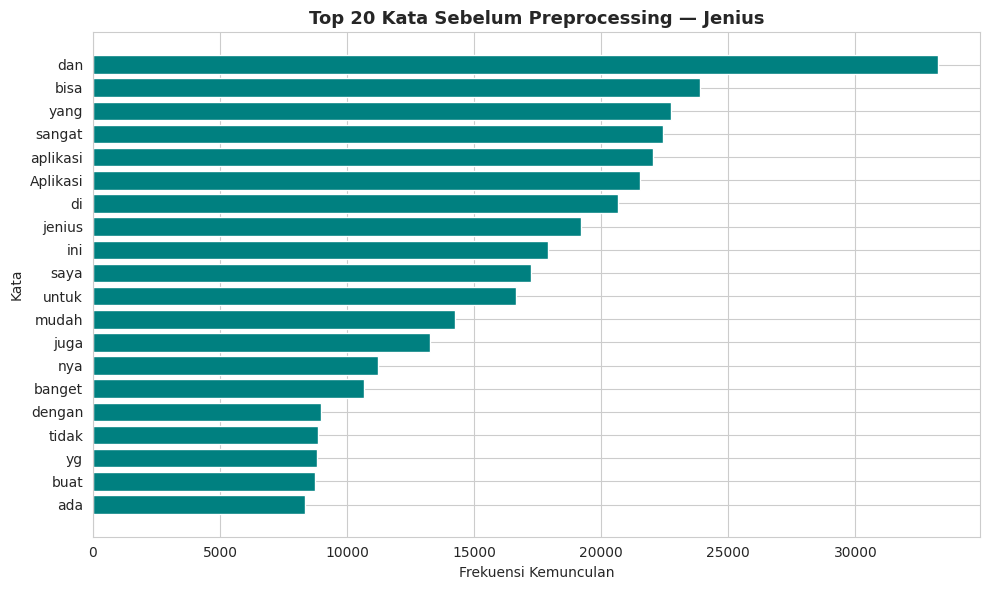

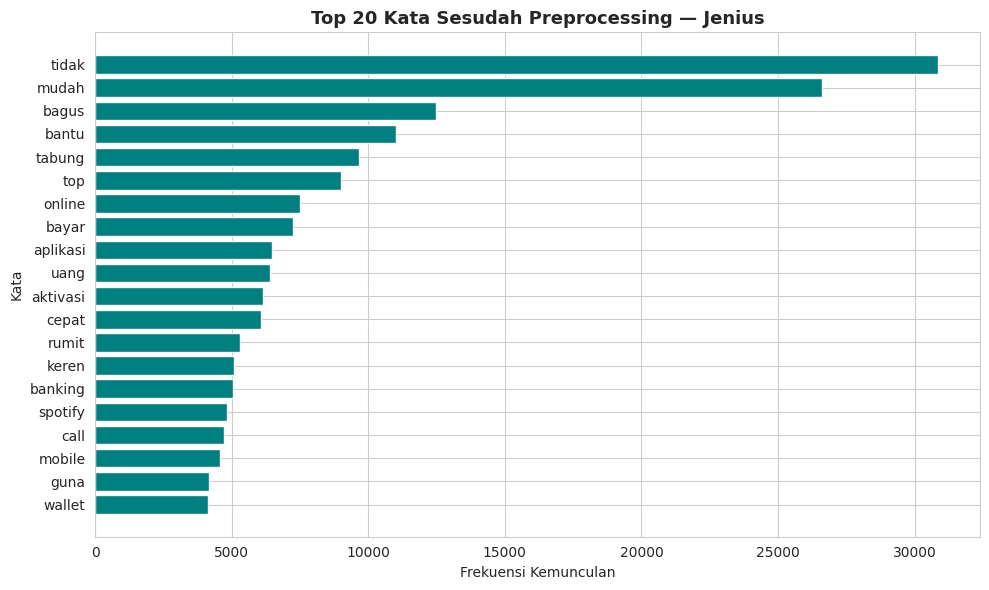

In [42]:
def tampilkan_frekuensi(seri_teks, judul):
    semua_kata = ' '.join(seri_teks.dropna().astype(str)).split()
    frekuensi = Counter(semua_kata)
    top_20 = frekuensi.most_common(20)
    df_top = pd.DataFrame(top_20, columns=['Kata', 'Frekuensi'])

    plt.figure(figsize=(10, 6))
    plt.barh(df_top['Kata'][::-1], df_top['Frekuensi'][::-1], color='teal')
    plt.xlabel('Frekuensi Kemunculan')
    plt.ylabel('Kata')
    plt.title(judul, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Sebelum preprocessing
tampilkan_frekuensi(df_jenius['content'],
                    'Top 20 Kata Sebelum Preprocessing — Jenius')

# Sesudah preprocessing
tampilkan_frekuensi(df_bersih['content_bersih'],
                    'Top 20 Kata Sesudah Preprocessing — Jenius')

##Simpan Dataset Final

In [43]:
output_path = 'cleandata_jenius.csv'
df_bersih.to_csv(output_path, index=False, encoding='utf-8')

print(f'✅ Data berhasil disimpan ke: {output_path}')
print(f'   Jumlah baris : {len(df_bersih):,}')
print(f'   Jumlah kolom : {df_bersih.shape[1]}')

✅ Data berhasil disimpan ke: cleandata_jenius.csv
   Jumlah baris : 76,731
   Jumlah kolom : 14
